# Ε Proyecto Epsilon | Análisis de Rentabilidad de Planes de Telecomunicaciones

## Contexto empresarial

Megaline es un operador de telecomunicaciones que ofrece a sus clientes dos planes de prepago: Surf y Ultimate. El departamento comercial busca identificar cuál de las dos tarifas genera mayores ingresos con el fin de optimizar la asignación del presupuesto publicitario y respaldar futuras decisiones estratégicas.

Para ello, se analizará el comportamiento de una muestra de clientes durante 2018, evaluando su consumo de llamadas, mensajes de texto y datos móviles. A partir de esta información se estimarán los ingresos generados por cada plan y se aplicarán herramientas estadísticas para determinar si existen diferencias significativas entre ambas tarifas.

## Objetivos

- Evaluar la calidad y consistencia de los datos disponibles.
- Analizar el comportamiento de consumo de los clientes.
- Calcular el uso mensual de minutos, mensajes y datos.
- Estimar los ingresos generados por cada usuario.
- Comparar el desempeño financiero de los planes Surf y Ultimate.
- Identificar patrones de consumo asociados a cada tarifa.
- Aplicar pruebas estadísticas para validar diferencias entre planes.
- Generar recomendaciones basadas en evidencia para apoyar la toma de decisiones comerciales.

## Conjuntos de datos utilizados

- users.csv
- calls.csv
- messages.csv
- internet.csv
- plans.csv

## Inicialización

Como primer paso del análisis, se importaron las librerías necesarias para la manipulación, transformación y visualización de los datos. Estas herramientas permitirán integrar información proveniente de múltiples tablas, realizar cálculos sobre el consumo de los clientes y desarrollar los análisis estadísticos requeridos para comparar el desempeño de los planes Surf y Ultimate.

In [ ]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from math import factorial
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

## Cargar datos

In [ ]:
# Carga los archivos de datos en diferentes DataFrames
users = pd.read_csv("/datasets/megaline_users.csv")
calls = pd.read_csv("/datasets/megaline_calls.csv")
messages = pd.read_csv("/datasets/megaline_messages.csv")
internet = pd.read_csv("/datasets/megaline_internet.csv")
plans = pd.read_csv("/datasets/megaline_plans.csv")


## Preparar los datos

## Tarifas

## Exploración inicial de los conjuntos de datos

Se realizó una revisión general de las cinco tablas que conforman el proyecto con el objetivo de comprender su estructura, volumen de información y posibles desafíos de calidad de datos antes de iniciar el análisis.

La base de usuarios contiene información de 500 clientes y sus planes contratados, así como variables demográficas y de suscripción. Se observa que la columna `churn_date` presenta valores ausentes en la mayoría de los registros, situación que resulta coherente ya que muchos clientes continuaban activos al momento de la extracción de los datos.

Las tablas de llamadas, mensajes e internet registran la actividad de los usuarios durante 2018 y reúnen más de 300 mil eventos de uso combinados. En una revisión inicial no se observan valores ausentes en estas fuentes, lo que proporciona una base sólida para calcular el consumo mensual de minutos, mensajes y datos móviles.

Por último, la tabla de planes contiene las características de las tarifas Surf y Ultimate, información fundamental para calcular los ingresos generados por cada cliente y comparar el desempeño financiero de ambos planes.

En conjunto, los datos presentan una estructura adecuada para analizar los patrones de consumo de los usuarios y determinar cuál de las tarifas genera mayores ingresos para la compañía.

In [ ]:
# Imprimimos la información general/resumida sobre el DataFrame de las tarifas

users.info()
calls.info()
messages.info()
internet.info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
<class 'pandas.core.frame.D

Se realizó una validación de la tabla que contiene las características de los planes Surf y Ultimate, ya que esta información será la base para calcular los ingresos generados por cada cliente.

La revisión mostró que la tabla contiene únicamente los dos planes disponibles y no presenta valores ausentes ni registros duplicados. Además, los límites de minutos, mensajes, datos móviles y tarifas adicionales se encuentran correctamente definidos para ambos planes.

In [ ]:
# Imprimimos una muestra de los datos para las tarifas
print(plans.sample(2))

# Busqueda de valores ausentes
print(plans.isna().sum())

# Busqueda de duplicados explícitos
print(plans.duplicated().sum())

# Busqueda de duplicados implícitos
pd.unique(plans.values.ravel())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  
messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64
0


array([50, 15360, 500, 20, 10, 0.03, 'surf', 1000, 30720, 3000, 70, 7,
       0.01, 'ultimate'], dtype=object)

In [ ]:
# Imprimimos la información general/resumida sobre el DataFrame de usuarios

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


Se realizó una exploración inicial de la información de los clientes para verificar la calidad de los datos y comprender las características de la base de usuarios de Megaline.

La revisión mostró que la tabla contiene información de 500 clientes y no presenta registros duplicados ni valores ausentes en las variables principales. Los únicos valores faltantes se encuentran en la columna `churn_date`, situación esperada debido a que la mayoría de los usuarios continuaba utilizando el servicio cuando se recopiló la información.

In [ ]:
# Imprimimos una muestra de datos para usuarios
print(users.sample(40))

# Busqueda de valores duplicados explícitos
print(users.duplicated().sum())

# Busqueda de valores faltantes
print(users.isna().sum())

# Busqueda de valores duplicados implícitos
pd.unique(users.values.ravel())

# Confirmación del nombre Anamaria
users[users["first_name"].str.contains("ana", case=False, na=False)]

     user_id first_name  last_name  age  \
182     1182       Jeff       Burt   39   
362     1362   Kenyetta   Mcknight   65   
55      1055    Patrick     Mclean   52   
219     1219      Gavin     Keller   51   
447     1447      Ramon     Hester   62   
259     1259     Etsuko      Perry   63   
421     1421       Zane      Hobbs   26   
465     1465    Arianna   Morrison   73   
115     1115    Yevette       Yang   21   
224     1224      Kelly       Cole   74   
381     1381     German     Burris   44   
158     1158      Robin   Thornton   20   
337     1337     Lucius     Arnold   31   
275     1275      Elvie  Velazquez   33   
493     1493     Cicely       Wynn   18   
310     1310    Vincent        Fry   73   
495     1495      Fidel     Sharpe   67   
193     1193   Lacresha      Olsen   18   
111     1111     Booker       Hahn   75   
438     1438     Harvey     Brooks   36   
38      1038    Olympia  Velazquez   32   
235     1235     Felton     Nguyen   50   
279     127

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
148,1148,Dwana,Moore,67,"Columbia, SC MSA",2018-11-04,surf,NaN
210,1210,Shanae,Carrillo,30,"Oklahoma City, OK MSA",2018-06-01,surf,NaN
324,1324,Romana,Moore,18,"Minneapolis-St. Paul-Bloomington, MN-WI MSA",2018-04-04,surf,NaN
380,1380,Lajuana,Kelley,35,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-09-04,ultimate,NaN
468,1468,Johana,Kim,55,"Denver-Aurora-Lakewood, CO MSA",2018-09-08,surf,NaN


## Tratamiento de usuarios sin fecha de cancelación

Se revisó la variable `churn_date`, la cual indica la fecha en que un cliente dejó de utilizar el servicio. Debido a que la mayoría de los usuarios continuaba activa al momento de la extracción de los datos, esta columna presentaba una gran cantidad de valores ausentes.

Para facilitar su interpretación durante el análisis, los valores faltantes fueron reemplazados por la etiqueta **"no abandonada"**, diferenciando claramente a los clientes activos de aquellos que cancelaron el servicio durante el período estudiado.

In [ ]:
users["churn_date"] = users["churn_date"].fillna("no abandonada")
print(users["churn_date"].sample(40))

174    no abandonada
434    no abandonada
458    no abandonada
140    no abandonada
18     no abandonada
35     no abandonada
352    no abandonada
40        2018-12-30
202    no abandonada
125    no abandonada
320    no abandonada
313    no abandonada
170    no abandonada
409    no abandonada
245    no abandonada
39     no abandonada
19     no abandonada
287    no abandonada
244    no abandonada
201    no abandonada
37     no abandonada
489    no abandonada
195    no abandonada
149    no abandonada
24     no abandonada
451       2018-12-10
209    no abandonada
323    no abandonada
255    no abandonada
273    no abandonada
188    no abandonada
259    no abandonada
153    no abandonada
333    no abandonada
206    no abandonada
277    no abandonada
433    no abandonada
48     no abandonada
72     no abandonada
52     no abandonada
Name: churn_date, dtype: object


Podemos ver que la tabla contiene más de 137 mil llamadas realizadas durante 2018 e incluye información sobre la fecha, duración e identificador del usuario asociado a cada registro. En una inspección preliminar no se observan valores ausentes, lo que proporciona una base sólida para analizar el uso del servicio de voz.

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()
calls.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Se realizó una exploración más detallada de los registros de llamadas para evaluar la calidad de los datos antes de calcular el consumo mensual de cada usuario.

La revisión confirmó que la tabla no presenta valores ausentes ni registros duplicados, lo que indica una buena integridad de la información. Además, cada llamada cuenta con un identificador único, una fecha de realización y la duración correspondiente.

In [ ]:
# Imprimimos una muestra de datos para las llamadas

# Busqueda de datos faltantes
calls.isna().sum()

# Busqueda de valores dulpicados explícitos
calls.duplicated().sum()

# Busqueda de duplicados implícitos
pd.unique(calls.values.ravel())
print(calls.sample(56))


              id  user_id   call_date  duration
26434   1099_761     1099  2018-08-14     10.05
19905   1076_303     1076  2018-11-20      8.58
40030   1147_863     1147  2018-09-03      0.00
106772  1377_324     1377  2018-12-11      0.00
31272   1117_246     1117  2018-06-12      7.67
14952   1060_334     1060  2018-11-17      4.10
22548   1082_619     1082  2018-08-17     14.60
23924    1090_96     1090  2018-05-21      0.00
40840    1151_18     1151  2018-11-23      7.01
63006   1226_405     1226  2018-12-19     17.90
78503    1281_71     1281  2018-10-16     11.48
1854    1009_276     1009  2018-05-13      0.00
29684   1112_291     1112  2018-11-25     19.26
38706   1144_643     1144  2018-09-02     14.16
123575  1436_237     1436  2018-12-07     18.15
845     1004_369     1004  2018-10-19      0.00
46610   1169_847     1169  2018-12-10      9.82
123818  1437_180     1437  2018-11-16     17.10
69121    1248_28     1248  2018-12-06      0.00
106880   1379_78     1379  2018-12-13   

La tabla contiene más de 76 mil SMS enviados por los clientes durante 2018 e incluye el identificador del mensaje, el usuario asociado y la fecha de envío. En esta primera revisión no se observan valores ausentes, lo que indica que la información se encuentra completa para las variables disponibles.

In [ ]:
# Imprimimos la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprime una muestra de datos para los mensajes
messages.sample(40)

# Busqueda de valores duplicados explícitos
messages.duplicated().sum()

# Busqueda de valores duplicados implícitos
pd.unique(messages.values.ravel())

# Busqueda de valores faltantes
messages.isna().sum()


id              0
user_id         0
message_date    0
dtype: int64

## Internet

Ahora podemos ver que la tabla contiene más de 104 mil sesiones de internet registradas por los clientes durante 2018 e incluye información sobre el usuario, la fecha de la sesión y la cantidad de datos consumidos en cada conexión. En esta primera revisión no se observan valores ausentes, lo que indica que la información se encuentra completa para las variables disponibles.

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Imprime una muestra de datos para el tráfico de internet
internet.sample(40)

# Busqueda de valores faltantes
internet.isna().sum()

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

## Estudiar las condiciones de las tarifas

Antes de calcular el consumo y los ingresos generados por los clientes, se revisaron las características de los planes Surf y Ultimate para confirmar las condiciones de facturación que se utilizarán durante el análisis.

La revisión confirmó que ambos planes presentan diferencias importantes en el costo mensual y en los límites incluidos de minutos, mensajes y datos móviles. Mientras Surf ofrece un costo inicial más bajo con límites de consumo más reducidos, Ultimate incluye una mayor cantidad de servicios dentro de la tarifa mensual.

In [ ]:
# Imprimimos las condiciones de la tarifa y asegúrate de que te quedan claras
plans.info()
plans.sample(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
1,1000,30720,3000,70,7,0.01,0.01,ultimate
0,50,15360,500,20,10,0.03,0.03,surf


Como parte de la construcción de las métricas de consumo, se calculó la cantidad de llamadas realizadas por cada cliente durante cada mes del año. Para ello, primero se transformó la fecha de llamada a formato de fecha y posteriormente se extrajo el mes de cada registro.

In [ ]:
# Calculamos el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls["call_date"] = pd.to_datetime(calls["call_date"])
calls["mes"] = calls["call_date"].dt.month
llamadas_al_mes = calls.groupby(["user_id", "mes"]).size().reset_index(name = "numero de llamadas")
print(llamadas_al_mes)
calls.info()

      user_id  mes  numero de llamadas
0        1000   12                  16
1        1001    8                  27
2        1001    9                  49
3        1001   10                  65
4        1001   11                  64
...       ...  ...                 ...
2253     1498   12                  39
2254     1499    9                  41
2255     1499   10                  53
2256     1499   11                  45
2257     1499   12                  65

[2258 rows x 3 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
 4   mes        137735 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
me

Una vez identificadas las llamadas realizadas por cada usuario, se calculó el total de minutos consumidos mensualmente. Esta agregación permite transformar miles de registros individuales en una métrica mensual mucho más útil para evaluar el comportamiento de los clientes y estimar los ingresos generados por cada plan.

Los resultados muestran una gran variabilidad en el uso del servicio de voz. Mientras algunos usuarios registran consumos relativamente bajos, otros superan ampliamente los límites incluidos en sus planes, alcanzando más de mil minutos en determinados meses.

In [ ]:
# Calculamos la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
calls.info()
calls["call_date"] = pd.to_datetime(calls["call_date"])
calls["duration"] = pd.to_numeric(calls["duration"])
calls["mes"] = calls["call_date"].dt.month
minutos_al_mes = calls.groupby(["user_id", "mes"])["duration"].sum().reset_index(name = "minutos al mes")
print(minutos_al_mes.sample(46))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
 4   mes        137735 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 5.3+ MB
      user_id  mes  minutos al mes
1734     1382    9         1159.29
274      1061   12          496.63
1467     1326   11          944.47
10       1004    5          181.58
1633     1359   12          419.09
439      1095    8           95.07
1115     1244   12          144.49
241      1056    8          329.36
1460     1324   12          986.15
1082     1236    7          503.74
874      1187    4          534.33
729      1156    9          311.69
882      1187   12

Para medir el uso del servicio de mensajería, se calculó el número total de SMS enviados por cada usuario en cada mes. Previamente, la fecha de envío fue convertida al formato adecuado para extraer el mes y consolidar la actividad a nivel mensual.

Esta agregación permite resumir el comportamiento de los clientes y comparar su consumo con los mensajes incluidos en los planes Surf y Ultimate. Los resultados muestran que el volumen de mensajes varía considerablemente entre usuarios y entre meses, lo que sugiere distintos patrones de uso del servicio.

La métrica obtenida será utilizada posteriormente para calcular posibles excedentes sobre los límites incluidos en cada tarifa y estimar con mayor precisión los ingresos generados por cada cliente.

In [ ]:
# Calculamos el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

messages["message_date"] = pd.to_datetime(messages["message_date"])
messages["mes"] = messages["message_date"].dt.month
mensajes_por_mes = messages.groupby(["user_id", "mes"]).size().reset_index(name = "mensajes por mes")
print(mensajes_por_mes)
messages.info()

      user_id  mes  mensajes por mes
0        1000   12                11
1        1001    8                30
2        1001    9                44
3        1001   10                53
4        1001   11                36
...       ...  ...               ...
1801     1496    9                21
1802     1496   10                18
1803     1496   11                13
1804     1496   12                11
1805     1497   12                50

[1806 rows x 3 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   mes           76051 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 2.3+ MB


Para medir el uso de datos móviles, se calculó el volumen total de tráfico de internet consumido por cada usuario en cada mes. Para ello, se transformó la fecha de cada sesión a formato de fecha y se extrajo el mes correspondiente, permitiendo consolidar el consumo mensual de datos.

In [ ]:
# Calculamos el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet["session_date"] = pd.to_datetime(internet["session_date"])
internet["mes"] = internet["session_date"].dt.month
volumen_traf_internet = internet.groupby(["user_id", "mes"])["mb_used"].sum().reset_index(name = "volumen de trafico de internet")
print(volumen_traf_internet)

internet.info()

      user_id  mes  volumen de trafico de internet
0        1000   12                         1901.47
1        1001    8                         6919.15
2        1001    9                        13314.82
3        1001   10                        22330.49
4        1001   11                        18504.30
...       ...  ...                             ...
2272     1498   12                        23137.69
2273     1499    9                        12984.76
2274     1499   10                        19492.43
2275     1499   11                        16813.83
2276     1499   12                        22059.21

[2277 rows x 3 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns

## Consolidación de las métricas mensuales de consumo

Una vez calculadas las métricas mensuales de llamadas, minutos, mensajes y consumo de internet, se integraron en una única tabla utilizando los identificadores de usuario y mes como claves de unión.

La fusión permitió construir una vista consolidada del comportamiento de cada cliente, reuniendo en un mismo registro toda la información necesaria para analizar su consumo mensual de servicios de telecomunicaciones.

Los valores ausentes que aparecen después de la integración son esperados, ya que no todos los usuarios utilizaron todos los servicios durante cada mes. Por ejemplo, algunos clientes realizaron llamadas e hicieron uso de internet sin enviar mensajes de texto, mientras que otros utilizaron únicamente determinados servicios.

In [ ]:
# Fusionamos los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
lista_de_dataframes = [llamadas_al_mes, minutos_al_mes, mensajes_por_mes, volumen_traf_internet]

df_final = lista_de_dataframes[0]

for dataframe in lista_de_dataframes[1:]:
    fusion = pd.merge(df_final, dataframe, on=["user_id", "mes"], how = "outer")
    df_final = fusion

print(df_final.info())
fusion.sample(30)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         2293 non-null   int64  
 1   mes                             2293 non-null   int64  
 2   numero de llamadas              2258 non-null   float64
 3   minutos al mes                  2258 non-null   float64
 4   mensajes por mes                1806 non-null   float64
 5   volumen de trafico de internet  2277 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 125.4 KB
None


,user_id,mes,numero de llamadas,minutos al mes,mensajes por mes,volumen de trafico de internet
508,1109,12,66.0,441.27,NaN,12497.47
2053,1451,11,88.0,567.18,60.0,14708.82
252,1059,4,29.0,205.71,20.0,3672.48
1710,1374,11,41.0,297.53,80.0,25042.12
372,1078,11,16.0,88.66,36.0,8193.15
879,1187,9,90.0,618.11,14.0,16160.35
1649,1362,8,111.0,618.62,71.0,14741.83
1725,1380,11,61.0,400.17,67.0,18413.87
1899,1412,8,140.0,868.99,54.0,14893.45
579,1125,12,65.0,489.51,54.0,22697.10


Antes de calcular los ingresos generados por cada cliente, se revisó la tabla de usuarios para confirmar la disponibilidad de la información necesaria sobre el plan contratado. Esta tabla contiene la relación entre cada usuario y la tarifa asignada, además de datos demográficos y de suscripción que permiten contextualizar el análisis.

La variable `plan` será fundamental en las siguientes etapas del proyecto, ya que permitirá asociar a cada usuario las condiciones tarifarias correspondientes de Surf o Ultimate. De esta manera, será posible comparar el consumo mensual de los clientes con los límites incluidos en cada plan y calcular los cargos adicionales cuando existan excedentes.

In [ ]:
# Añadimos la información de la tarifa
users.info()
users.sample(34)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
313,1313,Antoine,Baker,49,"San Francisco-Oakland-Berkeley, CA MSA",2018-05-24,surf,no abandonada
228,1228,Jude,Hale,26,"Detroit-Warren-Dearborn, MI MSA",2018-04-15,surf,no abandonada
160,1160,Steven,Morgan,44,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-02-05,surf,no abandonada
479,1479,Keesha,Burnett,44,"Riverside-San Bernardino-Ontario, CA MSA",2018-11-12,surf,no abandonada
398,1398,German,Thompson,30,"Denver-Aurora-Lakewood, CO MSA",2018-10-22,surf,no abandonada
196,1196,Noel,Dawson,46,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-01-14,ultimate,no abandonada
330,1330,Tobi,Kinney,48,"Las Vegas-Henderson-Paradise, NV MSA",2018-11-06,ultimate,no abandonada
370,1370,Nenita,Vasquez,49,"San Diego-Chula Vista-Carlsbad, CA MSA",2018-09-12,ultimate,no abandonada
401,1401,Charmain,Bryant,67,"Richmond, VA MSA",2018-08-24,ultimate,no abandonada
369,1369,Bernard,Mckee,69,"Milwaukee-Waukesha, WI MSA",2018-10-06,surf,no abandonada


Una vez integradas las métricas mensuales de llamadas, minutos, mensajes y consumo de internet, se incorporó la información de los clientes y las características de los planes tarifarios. Esta integración permitió construir una base de datos única que reúne tanto el comportamiento de consumo de los usuarios como las condiciones de facturación de cada tarifa.

Adicionalmente, los valores ausentes asociados al uso de servicios fueron reemplazados por cero, ya que en estos casos la ausencia de registros indica que el cliente no utilizó ese servicio durante el mes correspondiente y no un problema de calidad de los datos.

In [ ]:
# Calculamos el ingreso mensual para cada usuario
nuevo_df = pd.merge(df_final, users, on = ["user_id"], how = "inner")
nuevo_df2 = pd.merge(nuevo_df, plans, left_on = "plan", right_on = "plan_name", how = "outer")

# Generación de un bucle que cambie los valores ausentes por 0
lista_de_columnas = ["minutos al mes", "mensajes por mes", "volumen de trafico de internet"]

for columnas in lista_de_columnas:
    nuevo_df2 = nuevo_df2.fillna(0)
nuevo_df2.head()
nuevo_df2.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         2293 non-null   int64  
 1   mes                             2293 non-null   int64  
 2   numero de llamadas              2293 non-null   float64
 3   minutos al mes                  2293 non-null   float64
 4   mensajes por mes                2293 non-null   float64
 5   volumen de trafico de internet  2293 non-null   float64
 6   first_name                      2293 non-null   object 
 7   last_name                       2293 non-null   object 
 8   age                             2293 non-null   int64  
 9   city                            2293 non-null   object 
 10  reg_date                        2293 non-null   object 
 11  plan                            2293 non-null   object 
 12  churn_date                      22

### Llamadas

Se realizó una revisión de la columna `numero de llamadas` para confirmar que la información agregada durante la consolidación de los datos se hubiera incorporado correctamente. La inspección muestra registros con distintos niveles de actividad, incluyendo usuarios que no realizaron llamadas durante determinados meses, representados con valores iguales a cero.

In [ ]:
print(nuevo_df2["numero de llamadas"])

0       16.0
1        2.0
2        9.0
3       71.0
4       63.0
        ... 
2288     0.0
2289     0.0
2290     0.0
2291     0.0
2292     0.0
Name: numero de llamadas, Length: 2293, dtype: float64


## Comparación del consumo promedio de minutos por plan

El consumo promedio de minutos presenta un comportamiento relativamente similar entre los planes Surf y Ultimate a lo largo del año. En ambos casos se observa una tendencia creciente desde los primeros meses hasta el cierre del período analizado, lo que indica un aumento gradual en el uso del servicio de llamadas.

Aunque existen meses en los que uno de los planes registra un promedio ligeramente superior al otro, las diferencias observadas no son particularmente grandes. Durante la segunda mitad del año, ambos grupos mantienen consumos cercanos a los 400 minutos mensuales en promedio.

Además, se aprecia que los usuarios de ambos planes suelen permanecer por debajo de los límites de minutos incluidos en sus respectivas tarifas (500 minutos para Surf y 3000 minutos para Ultimate). Esto sugiere que, para la mayoría de los clientes, las llamadas no representan el principal factor de generación de cargos adicionales.

En general, el comportamiento de uso de llamadas resulta bastante similar entre los usuarios de Surf y Ultimate, aunque será necesario complementar este análisis con los patrones de mensajes, consumo de datos e ingresos para determinar cuál de los planes resulta más rentable para Megaline.

   plan_name  mes  minutos al mes
0       surf    1      192.840000
1       surf    2      280.851111
2       surf    3      310.970000
3       surf    4      332.380000
4       surf    5      377.053247
5       surf    6      407.208866
6       surf    7      424.523223
7       surf    8      387.169630
8       surf    9      390.992062
9       surf   10      405.692363
10      surf   11      399.599823
11      surf   12      447.475283
12  ultimate    1      183.162500
13  ultimate    2      379.861429
14  ultimate    3      285.701667
15  ultimate    4      316.508095
16  ultimate    5      383.664828
17  ultimate    6      349.811064
18  ultimate    7      403.767288
19  ultimate    8      397.274789
20  ultimate    9      413.287326
21  ultimate   10      425.168019
22  ultimate   11      420.477559
23  ultimate   12      433.012583


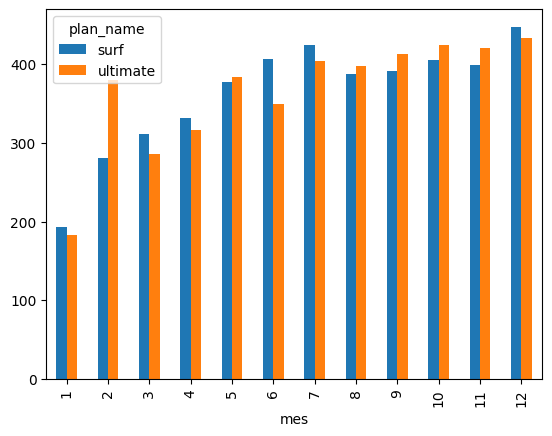

In [ ]:
# Comparamos la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

df_minutos = nuevo_df2.groupby(["plan_name", "mes"])["minutos al mes"].mean().reset_index()
print(df_minutos)

tabla = df_minutos.pivot(index="mes", columns="plan_name", values="minutos al mes")

tabla.plot(kind="bar")
plt.show()

## Distribución del consumo mensual de minutos

La distribución de minutos consumidos muestra un comportamiento bastante similar entre los usuarios de los planes Surf y Ultimate. En ambos casos, la mayor concentración de clientes se encuentra aproximadamente entre los 300 y 600 minutos de uso al mes, lo que indica patrones de consumo comparables para una parte importante de la base de usuarios.

Sin embargo, se observa que algunos clientes registran consumos considerablemente más altos, generando una cola hacia la derecha en ambas distribuciones. Esto sugiere la existencia de usuarios intensivos que realizan una cantidad de llamadas significativamente superior al promedio.

También destaca que la mayoría de los usuarios de Ultimate consume una cantidad de minutos muy inferior al límite incluido en su plan (3000 minutos), mientras que algunos usuarios de Surf se aproximan o incluso superan con mayor frecuencia el límite de 500 minutos. Este comportamiento podría traducirse en cargos adicionales para ciertos clientes de Surf, aspecto que tendrá un impacto directo en los ingresos generados por cada tarifa.

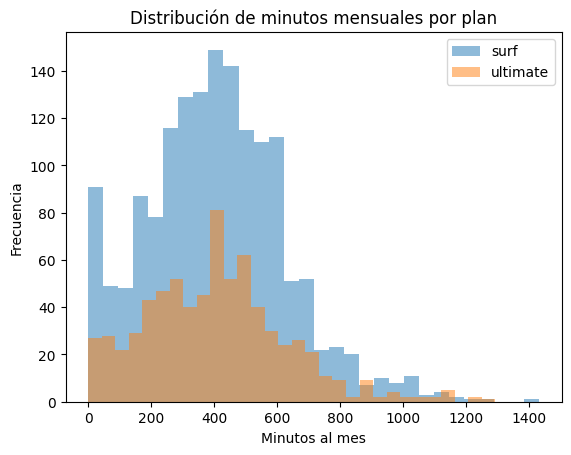

In [ ]:
# Comparamos el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.


# Filtrar por plan
surf = nuevo_df2[nuevo_df2["plan_name"] == "surf"]["minutos al mes"]
ultimate = nuevo_df2[nuevo_df2["plan_name"] == "ultimate"]["minutos al mes"]

# Graficar histogramas
plt.hist(surf, bins=30, alpha=0.5, label="surf")
plt.hist(ultimate, bins=30, alpha=0.5, label="ultimate")

# Etiquetas
plt.title("Distribución de minutos mensuales por plan")
plt.xlabel("Minutos al mes")
plt.ylabel("Frecuencia")

plt.legend()
plt.show()


Las estadísticas muestran que el consumo promedio de minutos es prácticamente el mismo en ambos planes. Los usuarios de **Surf** consumen en promedio 404,76 minutos al mes, mientras que los usuarios de **Ultimate** registran un promedio de 406,19 minutos.

Además, la varianza también presenta valores muy similares entre los dos grupos. Esto indica que la dispersión del consumo y la variabilidad entre usuarios son comparables en ambos planes, ya que existen clientes con niveles de uso bajos y otros con consumos considerablemente más altos en cada tarifa.

In [ ]:
# Calculamos la media y varianza de minutos al mes por plan
stats = nuevo_df2.groupby("plan_name")["minutos al mes"].agg(["mean", "var"])

print("Estadísticas por plan:")
print(stats)

Estadísticas por plan:
                 mean           var
plan_name                          
surf       404.762390  49135.104891
ultimate   406.193083  51640.971402


## Distribución del consumo mensual de minutos por plan

El diagrama de caja muestra que los usuarios de los planes Surf y Ultimate presentan patrones de consumo muy similares. La mediana de minutos utilizados se sitúa alrededor de los 400 minutos mensuales en ambos casos, lo que coincide con los promedios observados anteriormente.

También se aprecia una dispersión comparable entre los dos grupos, indicando que la variabilidad en el consumo de llamadas es semejante para los usuarios de ambos planes. Además, existen numerosos valores atípicos en las dos tarifas, correspondientes a clientes con un uso significativamente superior al habitual.

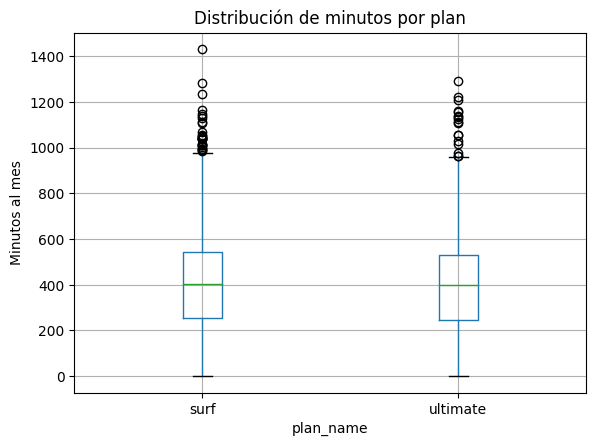

In [ ]:
# Trazamos un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# Boxplot separado por plan
nuevo_df2.boxplot(column="minutos al mes", by="plan_name")

plt.title("Distribución de minutos por plan")
plt.suptitle("")  # elimina título automático
plt.ylabel("Minutos al mes")

plt.show()


### Mensajes

## Comparación del promedio de mensajes enviados por plan

El volumen de mensajes enviados presenta diferencias más visibles entre los planes que las observadas anteriormente en el consumo de minutos. Durante prácticamente todos los meses del año, los usuarios del plan **Ultimate** registran un promedio de mensajes superior al de los usuarios del plan **Surf**.

Además, ambos planes muestran una tendencia creciente a lo largo del año, aunque el incremento es más pronunciado en Ultimate. Hacia los últimos meses del período analizado, los usuarios de este plan superan los 40 mensajes mensuales en promedio, mientras que los usuarios de Surf se mantienen por debajo de ese nivel.

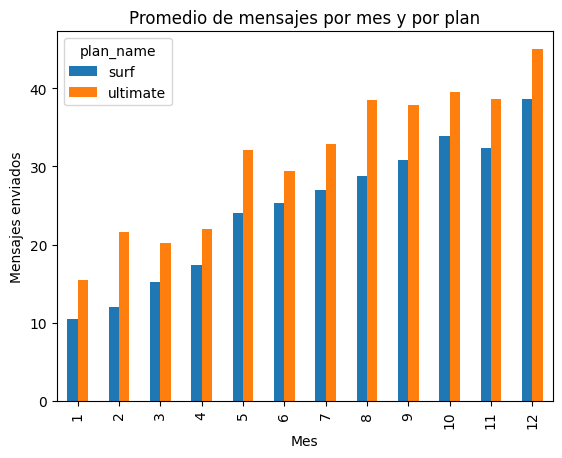

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
# 1. Agrupar y calcular promedio de mensajes por plan y mes
df_mensajes = nuevo_df2.groupby(["plan_name", "mes"])["mensajes por mes"].mean().reset_index()

# 2. Reorganizar datos para el gráfico
tabla = df_mensajes.pivot(index="mes", columns="plan_name", values="mensajes por mes")

# 3. Graficar
tabla.plot(kind="bar")

plt.title("Promedio de mensajes por mes y por plan")
plt.xlabel("Mes")
plt.ylabel("Mensajes enviados")

plt.show()


## Comparación del consumo promedio de datos móviles por plan

El consumo de internet presenta diferencias más marcadas que las observadas en llamadas y mensajes. Durante la mayor parte del año, los usuarios del plan **Ultimate** registran un consumo promedio de datos superior al de los usuarios del plan **Surf**, lo que sugiere una mayor intensidad en el uso de servicios de internet móvil.

En ambos planes se observa una tendencia creciente a medida que avanza el año, alcanzando los niveles más altos de consumo durante los últimos meses. Este comportamiento podría indicar una mayor dependencia de los servicios de datos móviles o un incremento general en la actividad de los usuarios a lo largo del período analizado.

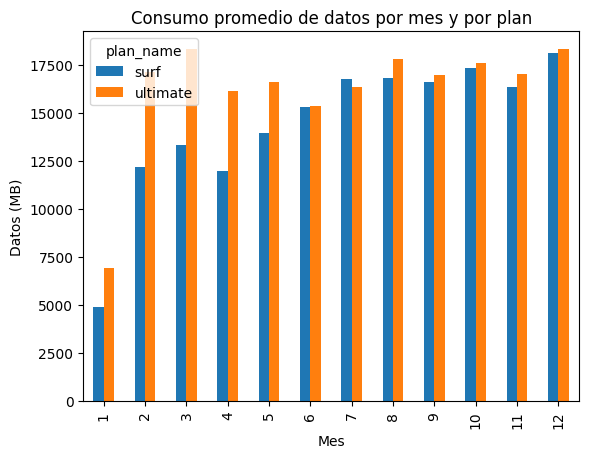

In [ ]:
# 1. Agrupamos y calculamos promedio de datos por plan y mes
df_datos = nuevo_df2.groupby(["plan_name", "mes"])["volumen de trafico de internet"].mean().reset_index()

# 2. Reorganizamos para graficar
tabla = df_datos.pivot(index="mes", columns="plan_name", values="volumen de trafico de internet")

# 3. Graficar
tabla.plot(kind="bar")

plt.title("Consumo promedio de datos por mes y por plan")
plt.xlabel("Mes")
plt.ylabel("Datos (MB)")

plt.show()


### Internet

## Análisis del consumo de internet por plan

El consumo de datos móviles muestra algunas diferencias entre los usuarios de los planes Surf y Ultimate. En promedio, los clientes de **Ultimate** consumen aproximadamente **17.215 MB** al mes, mientras que los clientes de **Surf** utilizan cerca de **16.558 MB**. Aunque Ultimate presenta un promedio ligeramente superior, la diferencia entre ambos grupos no es particularmente grande.

Las distribuciones observadas en los histogramas son similares y muestran una concentración importante de usuarios entre los 10.000 y 25.000 MB mensuales. Sin embargo, también existe una cola hacia la derecha en ambos planes, indicando la presencia de usuarios con consumos significativamente más altos que el promedio.

El diagrama de caja confirma esta situación. Las medianas de ambos planes son muy parecidas y la dispersión del consumo resulta comparable entre los grupos. Además, se observan numerosos valores atípicos, especialmente en Surf, donde algunos usuarios alcanzan niveles de consumo extraordinariamente elevados.

Un aspecto relevante para el negocio es que el consumo promedio de los usuarios de Surf supera el límite incluido de **15 GB (15.360 MB)** en varios casos, lo que puede generar cargos adicionales por datos excedentes. Por el contrario, los usuarios de Ultimate cuentan con un límite mucho más amplio de **30 GB (30.720 MB)**, reduciendo la probabilidad de pagos adicionales por este concepto.

En conjunto, los resultados sugieren que el uso de internet constituye una de las variables más importantes para explicar posibles diferencias de ingresos entre ambos planes, ya que el consumo de datos se acerca con frecuencia a los límites incluidos, especialmente en el plan Surf.

Estadísticas de consumo de internet por plan:
                   mean           var
plan_name                            
surf       16558.283490  6.421640e+07
ultimate   17214.699694  6.165229e+07


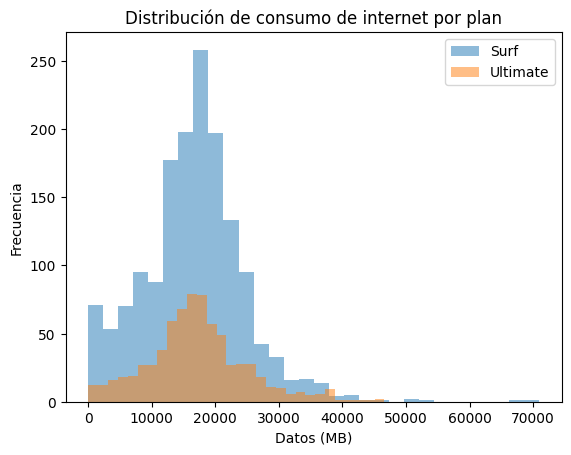

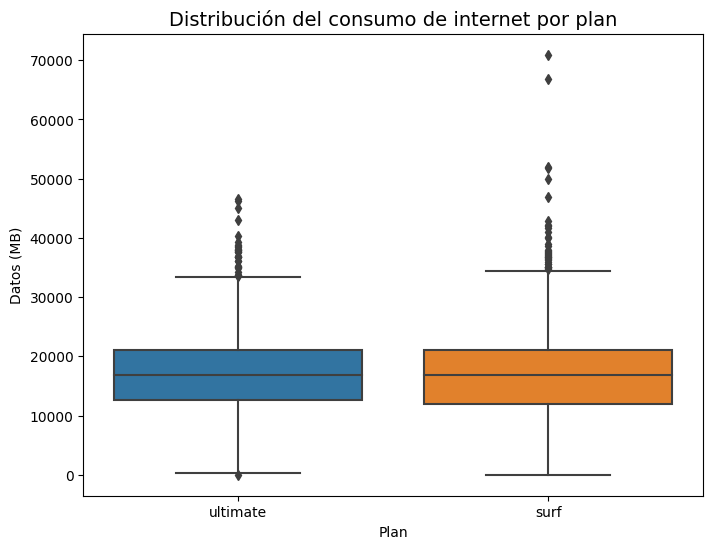

In [ ]:

# Media y varianza de internet por plan
stats_internet = nuevo_df2.groupby("plan_name")["volumen de trafico de internet"].agg(["mean", "var"])

print("Estadísticas de consumo de internet por plan:")
print(stats_internet)

# Separar los datos por plan
surf = nuevo_df2[nuevo_df2["plan_name"] == "surf"]["volumen de trafico de internet"]
ultimate = nuevo_df2[nuevo_df2["plan_name"] == "ultimate"]["volumen de trafico de internet"]

# Graficar histogramas
plt.hist(surf, bins=30, alpha=0.5, label="Surf")
plt.hist(ultimate, bins=30, alpha=0.5, label="Ultimate")

plt.title("Distribución de consumo de internet por plan")
plt.xlabel("Datos (MB)")
plt.ylabel("Frecuencia")

plt.legend()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética (mejora visual)
plt.figure(figsize=(8, 6))

# Boxplot
sns.boxplot(
    data=nuevo_df2,
    x="plan_name",
    y="volumen de trafico de internet"
)

# Títulos y etiquetas
plt.title("Distribución del consumo de internet por plan", fontsize=14)
plt.xlabel("Plan")
plt.ylabel("Datos (MB)")

# Mostrar
plt.show()

## Ingreso

Los resultados muestran una diferencia importante entre ambos planes. El plan **Ultimate** genera un ingreso promedio de aproximadamente **72,12 dólares por usuario al mes**, mientras que el plan **Surf** alcanza un promedio de **57,29 dólares**. Esto indica que, en términos de ingreso medio, Ultimate produce mayores ingresos para la compañía.

In [ ]:
# 1. Calcular excesos

nuevo_df2["minutos_extra"] = np.maximum(0, nuevo_df2["minutos al mes"] - nuevo_df2["minutes_included"])

nuevo_df2["mensajes_extra"] = np.maximum(0, nuevo_df2["mensajes por mes"] - nuevo_df2["messages_included"])

nuevo_df2["datos_extra_mb"] = np.maximum(0, nuevo_df2["volumen de trafico de internet"] - nuevo_df2["mb_per_month_included"])

nuevo_df2["datos_extra_gb"] = nuevo_df2["datos_extra_mb"] / 1024


# 2. Calcular costos extra

nuevo_df2["costo_minutos"] = nuevo_df2["minutos_extra"] * nuevo_df2["usd_per_minute"]

nuevo_df2["costo_mensajes"] = nuevo_df2["mensajes_extra"] * nuevo_df2["usd_per_message"]

nuevo_df2["costo_datos"] = nuevo_df2["datos_extra_gb"] * nuevo_df2["usd_per_gb"]


# 3. Calcular ingreso total

nuevo_df2["ingreso_total"] = (
    nuevo_df2["usd_monthly_pay"]
    + nuevo_df2["costo_minutos"]
    + nuevo_df2["costo_mensajes"]
    + nuevo_df2["costo_datos"]
)


# 4. Estadísticas por plan

estadisticas = nuevo_df2.groupby("plan_name")["ingreso_total"].agg([
    "mean",
    "median",
    "var",
    "std",
    "min",
    "max"
])

print(estadisticas)

                mean   median          var        std   min         max
plan_name                                                              
surf       57.293784  36.6818  2887.544971  53.735882  20.0  581.328509
ultimate   72.116080  70.0000   115.968081  10.768848  70.0  178.522764


## Distribución de los ingresos generados por cada plan

El diagrama de caja revela diferencias importantes en la forma en que los planes generan ingresos para Megaline. Aunque el plan **Ultimate** presenta un ingreso promedio superior, sus ingresos son mucho más estables y se concentran cerca de la tarifa mensual base de 70 dólares. Esto indica que la mayoría de sus usuarios rara vez excede los límites incluidos en el plan.

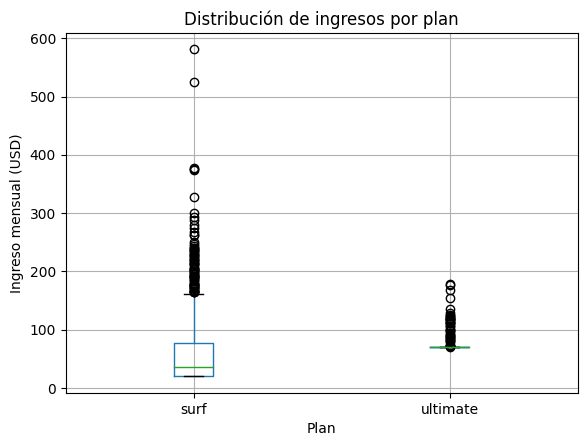

In [ ]:
# Graficar boxplot de ingresos por plan
nuevo_df2.boxplot(column="ingreso_total", by="plan_name")

plt.title("Distribución de ingresos por plan")
plt.suptitle("")
plt.xlabel("Plan")
plt.ylabel("Ingreso mensual (USD)")

plt.show()

## Prueba las hipótesis estadísticas

## Prueba de hipótesis sobre los ingresos de los planes

Con el objetivo de determinar si existe una diferencia significativa en los ingresos generados por los planes Surf y Ultimate, se aplicó una prueba t de Welch, adecuada para comparar medias entre dos grupos con varianzas diferentes.

Se plantearon las siguientes hipótesis:

- **H₀ (hipótesis nula):** el ingreso promedio generado por los usuarios de Surf es igual al ingreso promedio generado por los usuarios de Ultimate.
- **H₁ (hipótesis alternativa):** el ingreso promedio generado por los usuarios de Surf es diferente al ingreso promedio generado por los usuarios de Ultimate.

Los resultados obtenidos fueron:

- Estadístico t = **-10.49**
- Valor p = **4.88 × 10⁻²⁵**
- Nivel de significancia (α) = **0.05**

Dado que el valor p es considerablemente menor que el nivel de significancia establecido, se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística suficiente para concluir que los ingresos promedio generados por los usuarios de los planes Surf y Ultimate son diferentes.

Al complementar este resultado con el análisis descriptivo realizado anteriormente, se observa que el plan **Ultimate genera mayores ingresos promedio que el plan Surf**, lo que sugiere que esta tarifa aporta más ingresos para la compañía dentro de la muestra analizada.

Este hallazgo representa uno de los resultados más importantes del proyecto, ya que proporciona evidencia cuantitativa para apoyar decisiones comerciales relacionadas con la promoción y asignación del presupuesto publicitario entre ambos planes.

In [ ]:
# Probamos las hipótesis
from scipy import stats

# Separar datos por plan
surf = nuevo_df2[nuevo_df2["plan_name"] == "surf"]["ingreso_total"]
ultimate = nuevo_df2[nuevo_df2["plan_name"] == "ultimate"]["ingreso_total"]

# Prueba t (Welch)
t_stat, p_value = stats.ttest_ind(surf, ultimate, equal_var=False)

# Nivel de significancia
alpha = 0.05

print("t-stat:", t_stat)
print("p-value:", p_value)

# Decisión
if p_value < alpha:
    print("Rechazar H0 → los ingresos son diferentes")
else:
    print("No se rechaza H0 → no hay evidencia de diferencia")


t-stat: -10.489446388254443
p-value: 4.881852673479799e-25
Rechazar H0 → los ingresos son diferentes


## Prueba de hipótesis sobre los ingresos por región

Para evaluar si la ubicación geográfica influye en los ingresos generados por los clientes, se compararon los ingresos mensuales de los usuarios residentes en la región de **Nueva York-Nueva Jersey (NY-NJ)** frente a los usuarios del resto de las regiones incluidas en la muestra.

Se plantearon las siguientes hipótesis:

- **H₀ (hipótesis nula):** el ingreso promedio de los usuarios de NY-NJ es igual al ingreso promedio de los usuarios de las demás regiones.
- **H₁ (hipótesis alternativa):** el ingreso promedio de los usuarios de NY-NJ es diferente al ingreso promedio de los usuarios de las demás regiones.

Los resultados obtenidos fueron:

- Estadístico t = **-2.36**
- Valor p = **0.0186**
- Nivel de significancia (α) = **0.05**

Dado que el valor p es inferior al nivel de significancia establecido, se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística suficiente para afirmar que los ingresos promedio generados por los clientes de la región NY-NJ son significativamente diferentes de los ingresos generados por los clientes de otras regiones.

Este resultado sugiere que la ubicación geográfica puede estar asociada a diferencias en los patrones de consumo y, en consecuencia, en los ingresos obtenidos por Megaline. Sin embargo, la prueba no indica por sí sola cuál de los grupos genera mayores ingresos; para determinarlo es necesario complementar el análisis con las estadísticas descriptivas de los ingresos promedio de cada región.

In [ ]:
# Probamos las hipótesis
from scipy import stats

# Creación de grupo NY-NJ
ny_nj = nuevo_df2[nuevo_df2["city"].str.contains("NY-NJ", na=False)]["ingreso_total"]

# Creación de grupo resto
otros = nuevo_df2[~nuevo_df2["city"].str.contains("NY-NJ", na=False)]["ingreso_total"]

# Probamos t (Welch)
t_stat, p_value = stats.ttest_ind(ny_nj, otros, equal_var=False)

# Nivel de significancia
alpha = 0.05

print("t-stat:", t_stat)
print("p-value:", p_value)

# Decisión
if p_value < alpha:
    print("Rechazar H0 → ingresos diferentes entre regiones")
else:
    print("No se rechaza H0 → no hay diferencia significativa")


t-stat: -2.360069341431749
p-value: 0.018609472974971796
Rechazar H0 → ingresos diferentes entre regiones


## Conclusión

El análisis realizado sobre los clientes de Megaline permitió comprender los patrones de consumo asociados a los planes Surf y Ultimate, así como evaluar el impacto de estos comportamientos sobre los ingresos generados por la compañía.

Los resultados muestran que los usuarios de ambos planes presentan niveles de consumo relativamente similares en cuanto a llamadas telefónicas, aunque los clientes de Ultimate utilizan ligeramente más mensajes de texto y datos móviles en promedio. Sin embargo, la diferencia más importante se observó en los ingresos generados por cada tarifa.

Al calcular los ingresos mensuales considerando tanto la cuota base como los cargos adicionales por excedentes, se encontró que el plan **Ultimate genera mayores ingresos promedio por usuario que el plan Surf**. Además, los ingresos de Ultimate son más estables y predecibles, mientras que Surf presenta una alta variabilidad debido a que algunos clientes generan cargos adicionales significativos al superar los límites incluidos en su plan.

Las pruebas estadísticas confirmaron que la diferencia observada entre los ingresos promedio de ambos planes es estadísticamente significativa. Por lo tanto, existe evidencia suficiente para concluir que los usuarios de Ultimate generan, en promedio, más ingresos para Megaline que los usuarios de Surf.

Adicionalmente, se encontró evidencia de diferencias